In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [173]:
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 3.0.5
NumPy version: 2.5.3


In [174]:
import os

print(os.getcwd())

c:\Users\Hp\Documents\Github


In [175]:
import os

print(os.getcwd())

c:\Users\Hp\Documents\Github


In [176]:
import os

print(os.getcwd())

c:\Users\Hp\Documents\Github


In [177]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

C:\Users\Hp\AppData\Local\Temp\ipykernel_15784\2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [178]:
from pathlib import Path
import urllib.request
import tarfile

data_path = Path("datasets/housing")
data_path.mkdir(parents=True, exist_ok=True)

url = "https://github.com/ageron/data/raw/main/housing.tgz"
tgz_path = data_path / "housing.tgz"

urllib.request.urlretrieve(url, tgz_path)

with tarfile.open(tgz_path) as housing_tarball:
    housing_tarball.extractall(path=data_path)

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


C:\Users\Hp\AppData\Local\Temp\ipykernel_15784\1843998644.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path=data_path)


In [179]:
housing = pd.read_csv("datasets/housing/housing.csv")

In [180]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [181]:
housing.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [182]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


1. 20640 observations
2. 10 Attributes
3. longitude, latitude,housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value
4. Ocean_proximity
5. median_house_value
6. 207 missing values in total bedrooms

In [183]:
import matplotlib.pyplot as plt

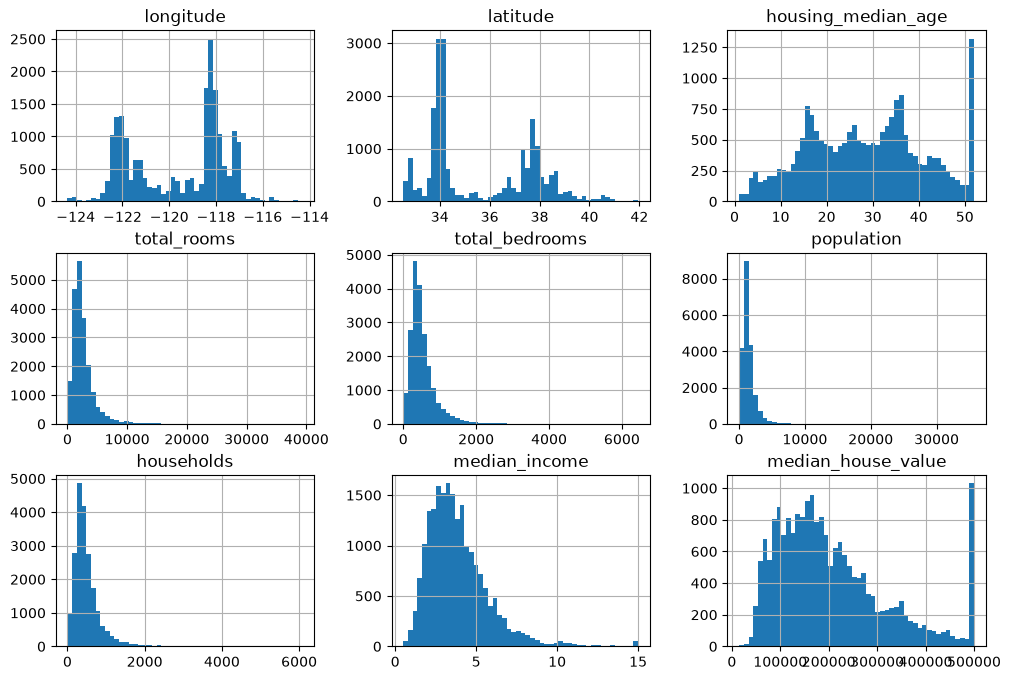

In [184]:
housing.hist(bins=50, figsize=(12, 8))
plt.show()

- median_income
- total_rooms, total_bedrooms, population, households
- Yes there are, this is noticed from the min and max values as displayed from the min and max values as displayed from the housing.describe() code display
- Yes there are, looking at the max values from different attributes and the median values.These indicate unusually large values.


In [185]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)

In [186]:
len(train_set), len(test_set)

(16512, 4128)

- We need test data to help us evaluate how well a model has learnt the data provided during the trainng phase and how well it performs with unseen data
- If we continue to use the test data while developing the model, the model adapts and learns the test dataand will then be unable to give an unbiased evaluation of the models performance.
- Preprocessing operations should only be learned on training data to prevent data leakage to the model thereby causing the modelto memorize the whole data cauding overfitting.

In [187]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3., 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)


In [188]:
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [189]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(
    housing, housing["income_cat"]
):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [190]:
housing["income_cat"].value_counts(normalize=True)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: proportion, dtype: float64

In [191]:
len(strat_train_set), len(strat_test_set)

(16512, 4128)

In [192]:
strat_test_set["income_cat"].value_counts(normalize=True)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: proportion, dtype: float64

In [193]:
strat_test_set["income_cat"].value_counts(normalize=True)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: proportion, dtype: float64

In [194]:
test_set["median_income"].describe()

count    4128.000000
mean        3.899013
std         1.869154
min         0.499900
25%         2.578625
50%         3.580050
75%         4.821875
max        15.000100
Name: median_income, dtype: float64

In [195]:
test_set["income_cat"] = pd.cut(
    test_set["median_income"],
    bins=[0., 1.5, 3., 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

In [196]:
test_set["income_cat"].value_counts(normalize=True)

income_cat
3    0.345203
2    0.307413
4    0.184109
5    0.120882
1    0.042393
Name: proportion, dtype: float64

- The random sampling created an income distribution that was a little bit different from the distribution of the complete dataset. For example, income category 2 showede 31.88% of the complete dataset but only 30.74% of the random set test set but looking at te dataset, the stratified dataset was somehow exactly the same to the complete dataset.

- Stratified sampling can therefore be preferable when an attribute has an important relationship with the target variable because it ensures that the different groups of that attribue is represented in the test set almost in the same proportion as the complete datasets. This helps the model to be evaluated with an appropriate amount of the test ++set.

In [197]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [198]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


In [199]:
strat_test_set.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

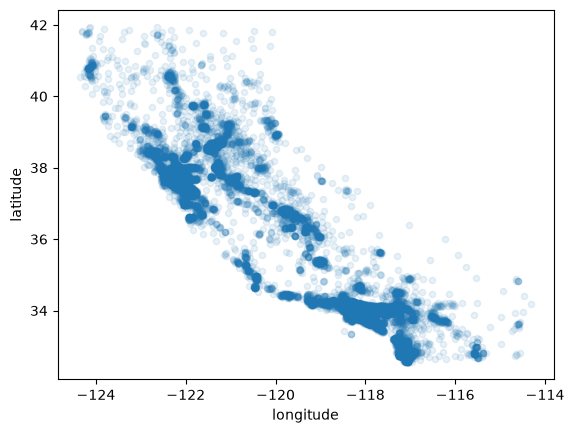

In [200]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.1
)

plt.show()

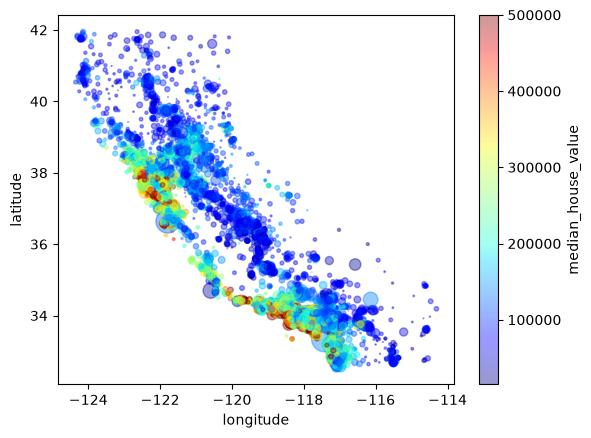

In [201]:
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    s=housing["population"] / 100,
    c="median_house_value",
    cmap=plt.get_cmap("jet"),
    colorbar=True
)

plt.show()

- The map shows that median house values vary between differenbt geographical regions. Some areas have a high concentration in several regions in the plotted geographical area
- The high density areas can be identified by the bigger circles. They have higher population values and are concentrated in several regions in the plotted geographical area.
- Yes house values appear to vary geographically. The different colors indicate different median house values. Some higher and some lower and this is displayed on the graph through the colors.
- Geographical information can be useful for predicting house pricews because housee values appear to vary depending on location. It can help our model identify the geographical patterns and the differences in the house values between areas.

In [202]:
corr_matrix = housing.corr(numeric_only=True)

In [203]:
corr_matrix["median_house_value"].sort_values(
    ascending=False
)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

- median_income has the stongest correlation with median_house_value with a correlation of approximately 0.688. This shows a strong positive linear relationship compared with the other attributes
- No, a strong correlation doesn't necessarily mean that one attribute causes the target to change. Correlation shaows the relationship between two variables but it doesn't prove that one causes the other to change.
- Yes, longitude, latitude and population have weak correlation, they may still be useful when combined with other attributes or when the relationship is not purely linear
- No, correlation is used to tell the relationship between attributes but models selection requires evaluating actual model performance and how well it generalizes to unseen data.

In [204]:
housing["rooms_per_household"] = (
    housing["total_rooms"] /
    housing["households"]
)

housing["bedrooms_per_room"] = (
    housing["total_bedrooms"] /
    housing["total_rooms"]
)

housing["population_per_household"] = (
    housing["population"] /
    housing["households"]
)

In [205]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3,6.281853,0.172096,2.181467


- Combining existing attributes is useful because we can create new attributes/features that provides meaningful information than the original attributes individually
- bedrooms_per_room is the engineered attribute that appears most promising because it has the striongest correlation with median_house_value among the 3 newly engineered feature.
- Creating too many unnecessary feature can make the dataset more complex and introduce the model to irrelevant information and this coukld lead to overfitting.

In [206]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(
    ascending=False
)

median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

In [207]:
housing.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              207
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
income_cat                    0
rooms_per_household           0
bedrooms_per_room           207
population_per_household      0
dtype: int64

In [208]:
imputer =SimpleImputer(strategy="median")

In [209]:
housing_num = housing.drop("ocean_proximity", axis=1)

In [210]:
imputer.fit(housing_num)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['longitude','latitude','housing_median_age',...,'rooms_per_household', 'bedrooms_per_room','population_per_household']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](13,)","[-118.49, 34.26, 29. ,..., 5.23, 0.2 , 2.82]"


In [211]:
X = imputer.transform(housing_num)

In [212]:
X.shape

(20640, 13)

In [213]:
X[:5]

array([[-1.22230000e+02,  3.78800000e+01,  4.10000000e+01,
         8.80000000e+02,  1.29000000e+02,  3.22000000e+02,
         1.26000000e+02,  8.32520000e+00,  4.52600000e+05,
         5.00000000e+00,  6.98412698e+00,  1.46590909e-01,
         2.55555556e+00],
       [-1.22220000e+02,  3.78600000e+01,  2.10000000e+01,
         7.09900000e+03,  1.10600000e+03,  2.40100000e+03,
         1.13800000e+03,  8.30140000e+00,  3.58500000e+05,
         5.00000000e+00,  6.23813708e+00,  1.55796591e-01,
         2.10984183e+00],
       [-1.22240000e+02,  3.78500000e+01,  5.20000000e+01,
         1.46700000e+03,  1.90000000e+02,  4.96000000e+02,
         1.77000000e+02,  7.25740000e+00,  3.52100000e+05,
         5.00000000e+00,  8.28813559e+00,  1.29516019e-01,
         2.80225989e+00],
       [-1.22250000e+02,  3.78500000e+01,  5.20000000e+01,
         1.27400000e+03,  2.35000000e+02,  5.58000000e+02,
         2.19000000e+02,  5.64310000e+00,  3.41300000e+05,
         4.00000000e+00,  5.81735160e

In [214]:
np.isnan(X).sum()

np.int64(0)

- Deleting the row is simple but it can resukt in losing useful data, especially when many rows contain missing values
- Deleting an attribute fixes the missing value problem but this potentially throws away useful information from the entire column
- Median imputation doesn't throw away the observation or an entire feature but introducews qan estimated value which is not necessarily the actual missing value
- The median should be calculated from the training data to avoid data from the test data set from leaking into the model development process. This prevents the model from overfitting and helps for an unbiased evaluation of the model on unseen data.

In [215]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [216]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat = housing[["ocean_proximity"]]

housing_cat_1hot = cat_encoder.fit_transform(
    housing_cat
)

In [217]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [218]:
housing_cat_1hot.toarray()[:5]

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]])

- We cannot simply assign the categories the values 1,2,3,4 and so on because this could make the model to think that the categories have a meaningful relationship order or numerical relationship
- One hot encoding converts each categories to binary feature(0,1) without creating artificial order.
- There are 5 encoded features created for tghe ocean_proximity since it has 5 unique categories.

In [219]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

housing_num_scaled = scaler.fit_transform(
    housing_num
)

In [220]:
housing_num_scaled[:5]

array([[-1.32783522,  1.05254828,  0.98214266, -0.8048191 , -0.97032521,
        -0.9744286 , -0.97703285,  2.34476576,  2.12963148,  1.89012782,
         0.62855945, -1.1460242 , -0.04959654],
       [-1.32284391,  1.04318455, -0.60701891,  2.0458901 ,  1.34827594,
         0.86143887,  1.66996103,  2.33223796,  1.31415614,  1.89012782,
         0.32704136, -0.98725423, -0.09251223],
       [-1.33282653,  1.03850269,  1.85618152, -0.53574589, -0.82556097,
        -0.82077735, -0.84363692,  1.7826994 ,  1.25869341,  1.89012782,
         1.15562047, -1.44051403, -0.02584253],
       [-1.33781784,  1.03850269,  1.85618152, -0.62421459, -0.71876767,
        -0.76602806, -0.73378144,  0.93296751,  1.16510007,  0.94189394,
         0.15696608, -0.49292537, -0.0503293 ],
       [-1.33781784,  1.03850269,  1.85618152, -0.46240395, -0.61197437,
        -0.75984669, -0.62915718, -0.012881  ,  1.17289952, -0.00633994,
         0.3447108 , -0.70614112, -0.08561576]])

- Feature scaling is necessary because numerical attributes can have very different ranges and scales. Scaling puts the numerical values on a more comparable scale which can help these algorithms work properlyly
- Standardization transforms the vaklues based on their mean and standard derivation. The resulting values have a mean close to 0 and a standard deviation close to 1
- Feature scaling does not fundamentally change the relationships between the features. It changes the scale or representation of the values but not the observations.
- Feature scaling is not required for every machine learning algorithm 

In [221]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

In [222]:
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [223]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

In [224]:
num_attribs = list(housing_num)

In [225]:
num_attribs

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'income_cat',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

In [226]:
cat_attribs = ["ocean_proximity"]

In [227]:
housing_prepared = full_pipeline.fit_transform(housing)

In [228]:
housing_prepared.shape

(20640, 18)

In [229]:
housing = strat_train_set.drop(
    "median_house_value",
    axis=1
)

In [230]:
housing_labels = strat_train_set[
    "median_house_value"
].copy()

In [231]:
housing_num = housing.drop(
    "ocean_proximity",
    axis=1
)

In [232]:
housing_cat = housing[
    ["ocean_proximity"]
]

In [233]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [234]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

In [235]:
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs)
])

In [236]:
housing_prepared = full_pipeline.fit_transform(housing)

In [237]:
housing_prepared.shape

(16512, 13)

In [238]:
num_attribs

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [239]:
cat_attribs

['ocean_proximity']

In [240]:
full_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

- Missing numerical values are handled in the SimpleImputer step
- The numerical feature is scaled in the Standardscaler step
- The ocean_proximity which is the categorical value is encoded in the columntransfer step
- Pipeline is preferrable to manually repeating the preprocessing operations because it organizes the preprocessing steps into a consistent workflow, reducing repetitive code and the possibility of mistakes. This can also be applied to new data or test data.

In [241]:
housing = strat_train_set.drop(
    "median_house_value",
    axis=1
)

housing_labels = strat_train_set[
    "median_house_value"
].copy()

take the training dataset and remove median_house_value and store it separately in house_labels

In [242]:
housing_prepared = full_pipeline.fit_transform(
    housing
)

In [243]:
housing_prepared.shape

(16512, 13)

.shape tells us the dimension of the data

Lab 2 
task  1.1
- The target variable is median_house_value
- The input feature are the attributes after removing the target value.
- There are 16,512 training observations
- There are 13 features after preprocessing
- The number of features can be different from the original number of attributes because of preprocessing. It changes the representation

In [244]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(
    housing_prepared,
    housing_labels
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-53381.26,-54311.56, 13122.77,...,198442.4 ,-43374.75,-35994.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.587e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[254.16,180.92,133.77,..., 17.92, 1.58, 0. ]"


we create a model named lin_reg and prepare it to be trained

- fit() trains the model using the input features and their known target values
- it learns the coefficient and an interfcept that defines the mathematical relationship between the input feature and the predicted median house value or the target variable
- No it doesn't, it learns the mathematical relationship from the training data and uses the relationship to oredict the house values.

In [245]:
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]
some_data_prepared = full_pipeline.transform(
    some_data
)
predictions = lin_reg.predict(
    some_data_prepared
)

print("Predictions:", predictions)
print("Actual values:", list(some_labels))

Predictions: [270886.93228264 334830.60618945 119856.18008898 109210.92995275
 305575.65811433]
Actual values: [458300.0, 483800.0, 101700.0, 96100.0, 361800.0]


Housing.iloc[:5] selects the first five rows of the input features.
housing_labels.iloc[:5] selects the corresponding five actual house values.
some_data contains the inputs.
some_labels contains the correct answers for comparison.

In [246]:
errors = some_labels.to_numpy() - predictions

comparison = pd.DataFrame({
    "Actual value": some_labels.to_numpy(),
    "Predicted value": predictions,
    "Prediction error": errors
})

comparison

,Actual value,Predicted value,Prediction error
0,458300.0,270886.932283,187413.067717
1,483800.0,334830.606189,148969.393811
2,101700.0,119856.180089,-18156.180089
3,96100.0,109210.929953,-13110.929953
4,361800.0,305575.658114,56224.341886


Task 3.1
- Not all of them are close to the actul values, observation 0 has an error of approximately 187,413 which is a substantial difference
- Yes observation 2 underestimated and observation 3 overestimated.
- Linear regression may noy capture all the complex relationships affecting the house prices.

In [248]:
from sklearn.metrics import mean_squared_error
import numpy as np
housing_predictions = lin_reg.predict(
    housing_prepared
)
lin_rmse = np.sqrt(
    mean_squared_error(
        housing_labels,
        housing_predictions
    )
)

print("RMSE:", lin_rmse)

RMSE: 68232.83515124217


In [249]:
housing_labels.median()

np.float64(179200.0)

In [250]:
lin_rmse / housing_labels.median() * 100

np.float64(38.076358901362816)

- RMSE measures the magnitude of the models prediction errors across the training dataset. it squares the errors, calculates the average and then takes the square roots.
- The units are the same as the target variables
- A lower RMSE is approximately 68,233 while the median value is 179200, this means the RMSE is about 38% of the median house value indicating that the model's prediction errors are relatively large compared with typical house prices.

In [251]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(
    random_state=42
)

tree_reg.fit(
    housing_prepared,
    housing_labels
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [252]:
housing_predictions = tree_reg.predict(
    housing_prepared
)

Tells the trained decision tree to predict the median house values for all the prepared training observations.

In [253]:
tree_rmse = np.sqrt(
    mean_squared_error(
        housing_labels,
        housing_predictions
    )
)

print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 0.0


- The decision tree has the lower training RMSE of 0.0, compare with linear regression RMSE of 68,232
- No, a model can fit the training data very closely but perform poorly on unseen data
- It may overfit the training data. memorizing patterns instead of learning the relationships that generalise the unseen data.

In [254]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    tree_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)
tree_rmse_scores = np.sqrt(-scores)

In [255]:
print("Mean RMSE:", tree_rmse_scores.mean())
print("Standard deviation:", tree_rmse_scores.std())

Mean RMSE: 68730.84229824627
Standard deviation: 1585.362175240545


- We use multiple folds to evaluate the model on different portions of the data. This helps us understand how well the model performs on observations it did not train on in each round.
- Scikit-learn uses a scoring convention where higher scores are better. Since lower mean squared error is better, it returns the negative value. We multiply the score by −1 before taking the square root to obtain a positive RMSE.
- The mean RMSE of 68,730.84 represents the average RMSE across the 10 validation folds. It gives us an estimate of how much prediction error to expect on data not used to fit the model in each fold.
- cross-validation provides a more useful estimate than a single training score bacause it evaluates the model on different portions of the data that were excluded from training in each round. Unlike the training score, it can reveal overfitting and provide a more useful estimate of performance on unseen data.

In [256]:
lin_scores = cross_val_score(
    lin_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

lin_rmse_scores = np.sqrt(-lin_scores)

print("Mean RMSE:", lin_rmse_scores.mean())
print("Standard deviation:", lin_rmse_scores.std())

Mean RMSE: 68316.17692806528
Standard deviation: 971.5373052470952


In [257]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_scores = cross_val_score(
    forest_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

forest_rmse_scores = np.sqrt(-forest_scores)

print("Mean RMSE:", forest_rmse_scores.mean())
print("Standard deviation:", forest_rmse_scores.std())

Mean RMSE: 48901.41320543065
Standard deviation: 670.5367015311969


- The Random Forest performs best among the three models according to mean cross-validation RMSE, with a value of 48,901.41, the lowest of the three results.
- The Random Forest has the lowest standard deviation of 670.54, meaning its RMSE results vary less across the 10 validation folds than those of the other two models.
- No. The Decision Tree had a training RMSE of 0.0, but its cross-validation RMSE is 68,730.84. Random Forest has a lower cross-validation RMSE of 48,901.41. This shows why a perfect training score does not necessarily mean a model will perform well on unseen data.
- It shows that we should not judge a model by its training error alone. Cross-validation helps us estimate how well models perform on data not used to train them and compare their performance more reliably.

In [258]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        "n_estimators": [3, 10, 30],
        "max_features": [2, 4, 6, 8]
    },
    {
        "bootstrap": [False],
        "n_estimators": [3, 10],
        "max_features": [2, 3, 4]
    }
]

In [259]:
forest_reg = RandomForestRegressor(
    random_state=42
)

grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    return_train_score=True
)
grid_search.fit(
    housing_prepared,
    housing_labels
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [2, 4, ...], 'n_estimators': [3, 10, ...]}, {'bootstrap': [False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` w

In [260]:
print(grid_search.best_params_)

{'max_features': 6, 'n_estimators': 30}


In [261]:
print(grid_search.best_estimator_)

RandomForestRegressor(max_features=6, n_estimators=30, random_state=42)


In [262]:
cvres = grid_search.cv_results_

for mean_score, params in zip(
    cvres["mean_test_score"],
    cvres["params"]
):
    print(
        "RMSE:", np.sqrt(-mean_score),
        "Parameters:", params
    )

RMSE: 63905.40638489696 Parameters: {'max_features': 2, 'n_estimators': 3}
RMSE: 54820.669276451044 Parameters: {'max_features': 2, 'n_estimators': 10}
RMSE: 52261.76881768009 Parameters: {'max_features': 2, 'n_estimators': 30}
RMSE: 60175.8568983983 Parameters: {'max_features': 4, 'n_estimators': 3}
RMSE: 52738.87699694067 Parameters: {'max_features': 4, 'n_estimators': 10}
RMSE: 49928.45305529516 Parameters: {'max_features': 4, 'n_estimators': 30}
RMSE: 59071.11432457014 Parameters: {'max_features': 6, 'n_estimators': 3}
RMSE: 51807.86350639332 Parameters: {'max_features': 6, 'n_estimators': 10}
RMSE: 49323.243711770556 Parameters: {'max_features': 6, 'n_estimators': 30}
RMSE: 58270.539830332804 Parameters: {'max_features': 8, 'n_estimators': 3}
RMSE: 51552.89517874721 Parameters: {'max_features': 8, 'n_estimators': 10}
RMSE: 49405.12590663484 Parameters: {'max_features': 8, 'n_estimators': 30}
RMSE: 61434.04454454081 Parameters: {'bootstrap': False, 'max_features': 2, 'n_estimators'

- The best combination was n_estimators=30 and max_features=6. This means the Random Forest uses 30 decision trees and considers six randomly selected features when searching for the best split at each tree node.
- The performance varied across the hyperparameter combinations tested. The RMSE values ranged from approximately 49,323.24 to 63,905.41, a difference of 14,582.17. The combination of max_features=6 and n_estimators=30 produced the lowest RMSE, while max_features=2 and n_estimators=3 produced the highest RMSE. This shows that the choice of hyperparameters affects the model's prediction performance.
- Systematic hyperparameter search helps us test different model settings and identify which combination gives better results. Instead of choosing settings randomly, Grid Search compares the combinations using cross-validation to find the best-performing configuration among those tested.

In [264]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_distribs = {
    "n_estimators": randint(
        low=1,
        high=200
    ),
    "max_features": randint(
        low=1,
        high=8
    )
}
forest_reg = RandomForestRegressor(
    random_state=42
)
rnd_search = RandomizedSearchCV(
    forest_reg,
    param_distributions=param_distribs,
    n_iter=10,
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42
)
rnd_search.fit(
    housing_prepared,
    housing_labels
)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_features': <scipy.stats....001F620AF87D0>, 'n_estimators': <scipy.stats....001F61D073E00>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric 

In [265]:
print(rnd_search.best_params_)

{'max_features': 7, 'n_estimators': 180}


In [266]:
print(
    "Grid Search RMSE:",
    np.sqrt(-grid_search.best_score_)
)

print(
    "Randomized Search RMSE:",
    np.sqrt(-rnd_search.best_score_)
)

Grid Search RMSE: 49323.243711770556
Randomized Search RMSE: 48704.58467953158


In [267]:
feature_importances = (
    grid_search.best_estimator_
    .feature_importances_
)

print(feature_importances)

[1.19607145e-01 1.07532793e-01 4.47470104e-02 3.47843589e-02
 3.04676303e-02 4.41524812e-02 2.78180627e-02 4.04647812e-01
 1.39017605e-02 1.62404281e-01 2.88019085e-04 2.53503952e-03
 7.11360612e-03]


In [268]:
print(full_pipeline.get_feature_names_out())

['num__longitude' 'num__latitude' 'num__housing_median_age'
 'num__total_rooms' 'num__total_bedrooms' 'num__population'
 'num__households' 'num__median_income' 'cat__ocean_proximity_<1H OCEAN'
 'cat__ocean_proximity_INLAND' 'cat__ocean_proximity_ISLAND'
 'cat__ocean_proximity_NEAR BAY' 'cat__ocean_proximity_NEAR OCEAN']


- The most important feature is median_income with an importance score of 0.405
- No feature importance indicates how much a feature contributes to the models prediction it doesn't prove that the feature causes house prices to change
- Yes the results are partly consistent with the correlation analysis. median_income had the strongest positive correlation and also had the highest feature importance score.
- Feature importance helps engineers identify which variables the model relies on most when makin predictions.

In [269]:
final_model = grid_search.best_estimator_

predictions = final_model.predict(
    housing_prepared
)

errors = housing_labels - predictions

error_rmse = np.sqrt(
    np.mean(errors ** 2)
)

print("RMSE:", error_rmse)

RMSE: 19313.761356524363


In [271]:
error_analysis = pd.DataFrame({
    "Actual value": housing_labels,
    "Predicted value": predictions,
    "Prediction error": errors
})

error_analysis.head()

,Actual value,Predicted value,Prediction error
13096,458300.0,427226.700000,31073.300000
14973,483800.0,470386.766667,13413.233333
3785,101700.0,100723.333333,976.666667
14689,96100.0,104696.666667,-8596.666667
20507,361800.0,310296.666667,51503.333333


- No. The prediction errors are different for each observation. Some predictions are very close to the actual values, while others have much larger errors.
- Yes. Some observations have much larger errors than others. For example, the first observation has an error of about $31,073, while the fifth has an error of about $51,503. These are larger errors compared with the observations whose errors are only a few thousand dollars.

In [272]:
final_test = strat_test_set.drop(
    "median_house_value",
    axis=1
)

final_test_labels = strat_test_set[
    "median_house_value"
].copy()

In [273]:
final_test_prepared = full_pipeline.transform(
    final_test
)

In [274]:
final_predictions = final_model.predict(
    final_test_prepared
)

In [275]:
final_rmse = np.sqrt(
    mean_squared_error(
        final_test_labels,
        final_predictions
    )
)

print("Final RMSE:", final_rmse)

Final RMSE: 49219.37618156016


In [276]:
from sklearn.metrics import mean_absolute_error

final_mae = mean_absolute_error(
    final_test_labels,
    final_predictions
)

print("Final MAE:", final_mae)

Final MAE: 31862.66853332257


- 49219.4
- 31862,67
- The final RMSE is approximately 49219.38 compared with the mean cross validatoion RMSE of 48,901.41. The test RSME is slightly higher which shows that the model performed marginally worst on the test set than its cross validation performance
- The model has an RMSE of approximately 49,219 and an MAE of approximately 31,863. The MAE indicates that the average absolute prediction error is about 31,863 price units, while the higher RMSE suggests that some larger errors may be contributing to the overall prediction error.

In [277]:
from sklearn.pipeline import Pipeline

full_prediction_pipeline = Pipeline([
    ("preparation", full_pipeline),
    ("model", final_model)
])

In [278]:
final_predictions = (
    full_prediction_pipeline.predict(
        final_test
    )
)

- The complete pipeline automatically performs the preprocessing steps defined in the full_pipeline, including handling missing values, encoding categorical variables, and scaling numerical features, depending on how the pipeline was configured. It then passes the prepared data to the trained model to generate predictions.
- Combining preprocessing and prediction is useful because it simplifies the machine learning workflow, reduces the risk of errors caused by inconsistent preprocessing, and ensures that new data is processed in the same way as the training data. It also makes the model easier to reuse and deploy in real-world applications.

In [279]:
from sklearn.svm import SVR

svm_reg = SVR(
    kernel="linear",
    C=1
)

In [280]:
svm_reg.fit(
    housing_prepared,
    housing_labels
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [281]:
svm_reg = SVR(
    kernel="rbf",
    C=30,
    gamma="scale"
)

svm_reg.fit(
    housing_prepared,
    housing_labels
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",30
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [282]:
from sklearn.model_selection import cross_val_score
import numpy as np

svm_scores = cross_val_score(
    svm_reg,
    housing_prepared,
    housing_labels,
    scoring="neg_mean_squared_error",
    cv=10
)

svm_rmse_scores = np.sqrt(-svm_scores)

print("Mean RMSE:", svm_rmse_scores.mean())
print("Standard deviation:", svm_rmse_scores.std())

Mean RMSE: 109418.21120274047
Standard deviation: 2015.975986873182
